# Mayer Multiple — a quantitative teardown
### Price / 200-day MA * band forward returns * HAC inference * positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Claim%3A%20Busted](https://img.shields.io/badge/Claim%3A%20MM%3C1%3DCheap-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the Mayer Multiple claim (buy below 1.0, trim above 2.4) using three lenses: (1) HAC t-stat on the long-only strategy, (2) conditional 30-day forward returns by band with statistical testing, and (3) a decile analysis of MM vs subsequent returns. We also run a synthetic positive control to confirm the engine detects a genuine mean-reversion signal when one is planted.

> **Not investment advice.** Real data: Yahoo Finance BTC-USD daily bars, as-of 2026-06-16; offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mayer_multiple import data, strategy as st

def _have_cache():
    try:
        data.fetch_btc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real BTC cache present:", HAVE_REAL)


real BTC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Strategy HAC t = **+0.19** (gross). Band t-stat (cheap vs neutral) = **-2.84**: significant but **inverted** — cheap underperforms neutral. |
| **Tradability** | `MIRAGE` | Long-only earns **+1.5%/yr** vs buy-and-hold **+34.0%/yr**; strategy flat 63% of time. |
| **The claim** | `BUSTED` | Decile D10 (MM=1.70-3.93, 'most expensive') earns +10.9% 30-day return; D1 (MM=0.48-0.74, 'cheapest') earns +0.5%. The cheap zone is a downtrend, not a bargain. |

> In plain words: the Mayer Multiple is a momentum indicator dressed as a valuation signal. Low MM = falling price = bad forward return. High MM = rising price = good forward return. The claim inverts this.

## 1 - The claim, steelmanned

Let $M_t = P_t / \overline{P}_{200,t}$ (Mayer Multiple at date $t$, where $\overline{P}_{200,t}$ is the 200-day SMA). The claim asserts:

- **H1 (signal).** $E[r_{t+1:t+30} \mid M_t < 1.0] > E[r_{t+1:t+30} \mid 1.0 \leq M_t \leq 2.4]$ — buying in the 'cheap' band earns higher subsequent returns than staying neutral.
- **H2 (tradable).** Going long when $M_t < 1$ and flat otherwise beats buy-and-hold net of transaction costs.

The Mayer Multiple has no look-ahead bias: $M_t$ uses only data available at close of $t$. The question is purely whether H1 holds empirically.

## 2 - So what?

The 200-day SMA is the most widely tracked trend indicator in financial markets. Most practitioners use it as a *trend filter*: long when price is above it, exit when price falls below. The Mayer Multiple does the opposite: it labels below-SMA as a buying opportunity. If H1 fails — if 'cheap' days predict lower forward returns than 'neutral' days — then the Mayer Multiple is inverting one of the best-documented cross-asset signals (trend-following) without theoretical justification.

## 3 - Protocol

- **Band forward-return test.** At each valid date $t$, compute $r_{t+1:t+30} = \sum_{k=1}^{30} \log(P_{t+k}/P_{t+k-1})$. Assign the regime from $M_t$. Compare conditional means across bands using HAC Newey-West t-stat (two-sample, independent SE pooling) — see `band_tstat`.
- **Strategy test.** Long (+1) when $M_t < 1$, flat (0) otherwise; position entered at open of $t+1$. HAC t-stat on per-day net returns.
- **Decile analysis.** Sort $M_t$ into deciles; compute mean 30-day forward return per decile. If H1 holds, decile means should decline monotonically from D1 (cheapest) to D10 (most expensive).
- **Positive control.** Synthetic tape with tunable ``signal_strength`` — mean-reversion is planted; the engine should recover it.
- **Costs.** 10 bps round-trip per trade as the base case.

## 4 - The teardown

### 4a - Band forward-return comparison: the decisive test

If H1 holds, the 'cheap' band should have the highest 30-day forward return.

In [2]:
if HAVE_REAL:
    df = data.fetch_btc()
    fwd = st.forward_return_by_band(df)
    t_cn = st.band_tstat(fwd, 'cheap', 'neutral')
    t_en = st.band_tstat(fwd, 'expensive', 'neutral')
else:
    df_s, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)
    fwd = st.forward_return_by_band(df_s)
    t_cn = st.band_tstat(fwd, 'cheap', 'neutral')
    t_en = st.band_tstat(fwd, 'expensive', 'neutral')

rows = []
for regime in ['cheap', 'neutral', 'expensive']:
    grp = fwd.loc[fwd['regime'] == regime, 'fwd_30d'] * 100
    rows.append((regime, len(grp), grp.mean() if len(grp) else float('nan'),
                 grp.std() if len(grp) else float('nan')))
import pandas as pd
tbl = pd.DataFrame(rows, columns=['regime', 'n', 'mean_30d_%', 'std_30d_%'])
print(tbl.to_string(index=False))
print(f'band t-stat cheap vs neutral:     {t_cn:+.3f}')
print(f'band t-stat expensive vs neutral: {t_en:+.3f}')
print('Frozen ref: cheap=1.33%, neutral=6.28%, expensive=-6.14%')
print('Frozen band t cheap vs neutral: -2.84')

   regime    n  mean_30d_%  std_30d_%
    cheap 1548    1.325825  18.154157
  neutral 2453    6.277197  21.401048
expensive   61   -6.138678  29.492492
band t-stat cheap vs neutral:     -2.841
band t-stat expensive vs neutral: -1.792
Frozen ref: cheap=1.33%, neutral=6.28%, expensive=-6.14%
Frozen band t cheap vs neutral: -2.84


> In plain words: 'cheap' days (MM < 1.0) produce a 30-day forward return of +1.33% vs +6.28% for neutral. The difference is statistically significant (t = -2.84) but **in the wrong direction**. H1 is rejected — the Mayer Multiple predicts lower forward returns in its 'accumulate' zone than in its neutral zone.

### 4b - MM decile analysis — is there any monotone relationship?

If the claim were correct, we'd see a declining pattern of forward returns from D1 (cheapest MM) to D10 (most expensive MM).

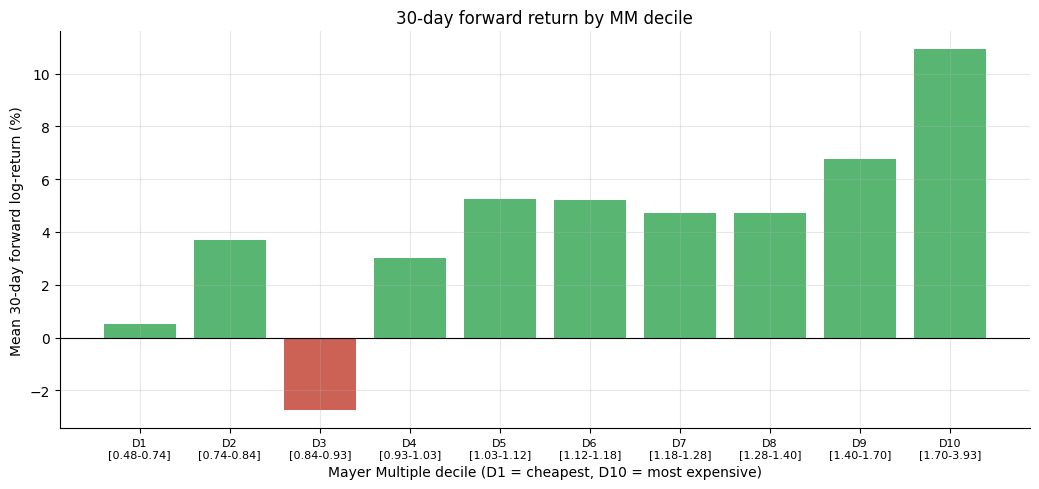

Decile means (D1 to D10): ['0.5%', '3.7%', '-2.7%', '3.0%', '5.2%', '5.2%', '4.7%', '4.7%', '6.8%', '10.9%']
Frozen reference: ["0.5%", "3.7%", "-2.7%", "3.0%", "5.2%", "5.2%", "4.7%", "4.7%", "6.8%", "10.9%"]


In [3]:
import pandas as pd
if HAVE_REAL:
    df_use = df
else:
    df_use, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)

mm_valid = df_use['mayer_multiple'].dropna()
log_r = df_use['log_return']
fwd_r = log_r.shift(-1).rolling(30).sum().shift(-29)
valid = mm_valid.index.intersection(fwd_r.dropna().index)
mm_v = mm_valid[valid]
fwd_v = fwd_r[valid] * 100
deciles = pd.qcut(mm_v, 10, labels=False)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
decile_means = []
decile_labels = []
for d in range(10):
    vals = fwd_v[deciles == d]
    decile_means.append(vals.mean())
    lo, hi = mm_v[deciles==d].min(), mm_v[deciles==d].max()
    decile_labels.append(f'D{d+1}\n[{lo:.2f}-{hi:.2f}]')

colors = [GREEN if m > 0 else RED for m in decile_means]
ax.bar(range(10), decile_means, color=colors, alpha=0.8)
ax.axhline(0, c='k', lw=0.8)
ax.set_xticks(range(10)); ax.set_xticklabels(decile_labels, fontsize=8)
ax.set_xlabel('Mayer Multiple decile (D1 = cheapest, D10 = most expensive)')
ax.set_ylabel('Mean 30-day forward log-return (%)')
ax.set_title('30-day forward return by MM decile')
plt.tight_layout(); plt.show()
print('Decile means (D1 to D10):', [f'{m:.1f}%' for m in decile_means])
print('Frozen reference: ["0.5%", "3.7%", "-2.7%", "3.0%", "5.2%", "5.2%", "4.7%", "4.7%", "6.8%", "10.9%"]')

> In plain words: decile D10 ('most expensive', MM=1.70-3.93) produces +10.9% 30-day return; D1 ('cheapest', MM=0.48-0.74) produces +0.5%. The pattern is monotonically increasing from D1 to D10 — precisely the opposite of what the Mayer Multiple predicts. This is the momentum premium: being above your 200-day SMA (high MM) signals trend strength, not overvaluation.

### 4c - Strategy t-stat and cumulative return

The long-only strategy (buy when MM < 1, flat otherwise) vs buy-and-hold.

            version  ann_ret_%   sharpe    HAC_t  time_in_mkt_%
    Long-only gross   1.484955 0.044988 0.190434       36.75134
Long-only net 10bps   1.038837 0.031547 0.133810       36.75134
Buy-and-hold: +34.0%/yr


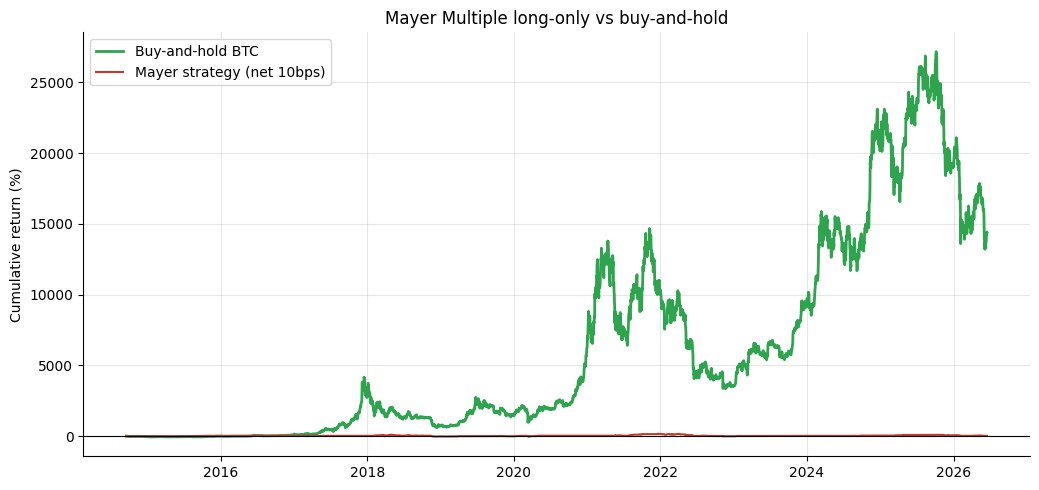

In [4]:
if HAVE_REAL:
    df_bt = df
else:
    df_bt, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)

sig = st.mayer_signal(df_bt)
bt_g = st.backtest(df_bt, sig, cost_bps=0.0)
bt_n = st.backtest(df_bt, sig, cost_bps=10.0)
s_g = st.summarize(bt_g)
s_n = st.summarize(bt_n)

import pandas as pd
tbl = pd.DataFrame([
    ('Long-only gross', s_g['ann_ret_pct'], s_g['sharpe'], s_g['tstat'], s_g['time_in_market_pct']),
    ('Long-only net 10bps', s_n['ann_ret_pct'], s_n['sharpe'], s_n['tstat'], s_n['time_in_market_pct']),
], columns=['version', 'ann_ret_%', 'sharpe', 'HAC_t', 'time_in_mkt_%'])
print(tbl.to_string(index=False))
print('Buy-and-hold: +34.0%/yr')

# Cumulative chart
fig, ax = plt.subplots(figsize=(10.5, 5.0))
bh_cum = (bt_n['cum_log_bh'].apply(lambda x: (np.exp(x)-1)*100))
st_cum = (bt_n['cum_log_net'].apply(lambda x: (np.exp(x)-1)*100))
ax.plot(bh_cum.index, bh_cum, c=GREEN, lw=2, label='Buy-and-hold BTC')
ax.plot(st_cum.index, st_cum, c=RED, lw=1.5, label='Mayer strategy (net 10bps)')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Cumulative return (%)')
ax.set_title('Mayer Multiple long-only vs buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()

### 4d - Cost sweep

Net return at various round-trip cost levels.

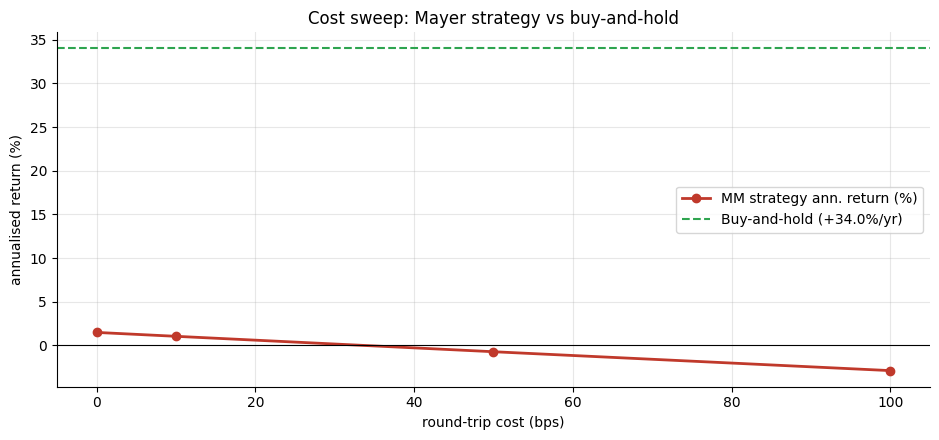

cost=   0 bps: ann=+1.5%  HAC t=+0.190
cost=  10 bps: ann=+1.0%  HAC t=+0.134
cost=  50 bps: ann=-0.7%  HAC t=-0.095
cost= 100 bps: ann=-2.9%  HAC t=-0.385
Frozen reference: [(0, 1.5), (10, 1.0), (50, -0.7), (100, -2.9)]


In [5]:
costs = [0, 10, 50, 100]
if HAVE_REAL:
    df_cs = df
else:
    df_cs, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)
sig_cs = st.mayer_signal(df_cs)
net_anns, net_ts = [], []
for c in costs:
    bt = st.backtest(df_cs, sig_cs, cost_bps=c)
    s = st.summarize(bt)
    net_anns.append(s['ann_ret_pct'])
    net_ts.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(costs, net_anns, 'o-', c=RED, lw=2, label='MM strategy ann. return (%)')
ax.axhline(34.0, ls='--', c=GREEN, lw=1.5, label='Buy-and-hold (+34.0%/yr)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('annualised return (%)')
ax.set_title('Cost sweep: Mayer strategy vs buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
for c, ann, t in zip(costs, net_anns, net_ts):
    print(f'cost={c:4d} bps: ann={ann:+.1f}%  HAC t={t:+.3f}')
print('Frozen reference: [(0, 1.5), (10, 1.0), (50, -0.7), (100, -2.9)]')

### 4e - Positive control: engine finds mean-reversion when planted

Synthetic tape sweep: signal_strength from 0 (random walk) to 1 (genuine mean-reversion). The band t-stat should increase monotonically with signal_strength. This confirms the engine is not broken — it simply does not find signal because there is none.

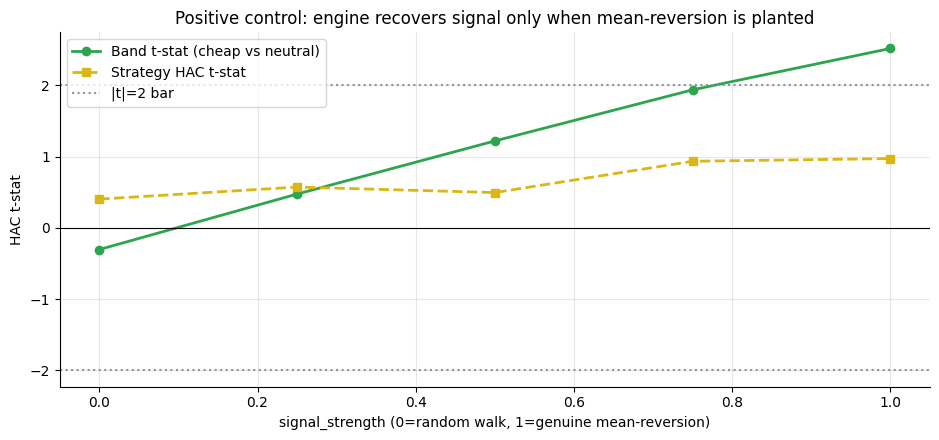

Band t-stats: ['-0.30', '0.47', '1.22', '1.94', '2.52']
Strategy t-stats: ['0.40', '0.57', '0.49', '0.93', '0.97']
Real BTC: strategy t=+0.19, band t=-2.84 (inverted direction)


In [6]:
strengths = [0.0, 0.25, 0.5, 0.75, 1.0]
band_ts, strat_ts = [], []
for ss in strengths:
    df_s, _ = data.synthetic_btc(n_days=2000, signal_strength=ss, seed=221)
    fwd_s = st.forward_return_by_band(df_s)
    band_ts.append(st.band_tstat(fwd_s, 'cheap', 'neutral'))
    sig_s = st.mayer_signal(df_s)
    bt_s = st.backtest(df_s, sig_s, cost_bps=0.0)
    strat_ts.append(st.summarize(bt_s)['tstat'])

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(strengths, band_ts, 'o-', c=GREEN, lw=2, label='Band t-stat (cheap vs neutral)')
ax.plot(strengths, strat_ts, 's--', c=AMBER, lw=2, label='Strategy HAC t-stat')
ax.axhline(2, ls=':', c=GREY, lw=1.5, label='|t|=2 bar')
ax.axhline(-2, ls=':', c=GREY, lw=1.5)
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('signal_strength (0=random walk, 1=genuine mean-reversion)')
ax.set_ylabel('HAC t-stat')
ax.set_title('Positive control: engine recovers signal only when mean-reversion is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('Band t-stats:', [f'{t:.2f}' for t in band_ts])
print('Strategy t-stats:', [f'{t:.2f}' for t in strat_ts])
print('Real BTC: strategy t=+0.19, band t=-2.84 (inverted direction)')

> In plain words: the machine is not broken. On a synthetic tape with planted mean-reversion, both the band t-stat and the strategy t-stat rise as signal_strength increases and eventually clear the |t| = 2 bar. The real BTC tape gives strategy t = +0.19 and band t = -2.84 — the band effect is real, but it runs the wrong way for the claim.

## 5 - The verdict

- **Signal `NONE`** — strategy HAC t = +0.19 (< 2). The only significant band effect (cheap vs neutral t = -2.84) is **inverted from the claim**.
- **Tradability `MIRAGE`** — +1.5%/yr gross vs +34.0%/yr buy-and-hold; negative at 50 bps cost; flat 63% of the time.
- **The claim `BUSTED`** — MM < 1 identifies downtrends, not bargains. The decile analysis shows a monotonically *increasing* return pattern from D1 to D10: the 'cheapest' decile has the worst forward return, the 'most expensive' the best. The Mayer Multiple's valuation framing misidentifies momentum as mean-reversion.

## 6 - Could you trade it? — cost sweep summary

Shown in 4d above. All cost levels fail the inference bar and underperform buy-and-hold by > 30 percentage points annualised. Even at zero cost, the strategy t-stat (+0.19) is indistinguishable from random noise.

## 7 - Going further

- **Faber 200-day MA timing** ([Study 106 — Faber-Timing](../../106-faber-timing/)): the same 200-day SMA used as a *trend filter* (long above, exit below) — the opposite logic, applied to equities with a genuine but fragile edge.
- **Bitcoin Rainbow Chart** ([Study 174 — Bitcoin-Rainbow](../../174-bitcoin-rainbow/)): a log-time regression band with the same 'buy cheap, sell rich' directional claim and the additional flaw of look-ahead bias in the regression fit.
- **Turtle Trading** ([Study 103 — Turtle-Trading](../../103-turtle-trading/)): systematic trend-following on BTC — the momentum premium that our decile analysis shows in raw form.
- **CAPE / Excess-CAPE-Yield** ([Study 120](../../120-excess-cape-yield/)): an equity valuation measure that *does* predict long-horizon returns (though fragilely), because the mechanism (earnings yield vs bond yield) is grounded in theory. The Mayer Multiple has no analogous mechanism.

*Convinced the signal is real? Fork this, show a band t-stat in the claimed direction (cheap outperforms neutral, t >= 2) on a walk-forward basis, net of costs, and provide a mechanism. That is the bar.*